# CAFÉ — one line, a full benchmark

> **The whole thesis of this library: one line of code runs a complete, *honest*
> analysis.** No config, no fitting, no plumbing.

This notebook benchmarks CAFÉ's imputation against live baselines and the published
state-of-the-art — with a single call, `cafe.benchmark(...)`.

**The honest framing up front — the "two-of-three".** Prior strong imputers pick at most
two of three properties: **causal / point-in-time**, **CPU-only**, and **competitive with
bidirectional deep SOTA**. The published front-runners — SAITS, BRITS, Transformer, CSDI,
ImputeFormer, FGTI — are all **bidirectional** (to fill `X[t]` they look at the *whole
window, including the future*) **and GPU-trained**. Bidirectional filling is a *smoothing*
task; in quantitative finance it is literally *forbidden look-ahead bias*
([Blanchet–Pelger 2022](https://arxiv.org/abs/2202.00871)). CAFÉ is **causal** — it fills
`X[t]` from data `≤ t` only, so it is backtest-safe by construction — **CPU-only**
(`numpy`, no GPU, no training), and lands **in the same accuracy band** as those
bidirectional deep models. That combination is, as of today, essentially unoccupied.

**What this notebook will and will not claim.** Every baseline below is *run live* on the
**same mask, same seed, same held-out cells** — apples-to-apples. The published deep
numbers are shown only as **clearly-labelled, different-protocol context**, never merged
with the live results and **CAFÉ is never ranked among them**. They come from one
reconciled registry, [`bench/refs_published.py`](../bench/refs_published.py); where two
sources disagree on a cell, **both values are kept** (we do not cherry-pick the flattering
one). Under the TSI-Bench source CSDI (0.102) is the *lowest* published Beijing MAE, so we
make **no protocol-independent "lowest MAE" claim**.

## 0 · Setup

In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import numpy as np
import matplotlib.pyplot as plt
import cafe
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("CAFÉ", cafe.__version__)

CAFÉ 0.1.0


## 1 · The one-liner

`cafe.benchmark()` with no arguments runs on a self-contained synthetic dataset — CAFÉ
against several baselines, **same held-out cells, same seed, scored identically**. That's
the entire API.

In [2]:
cafe.benchmark()

CAFÉ benchmark — synthetic  (600×20, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.150    0.202   17.0%    0.09s ★
  LOCF                0.323    0.409   36.5%    0.00s
  Holt (lvl+tr)       0.434    0.542   49.0%    0.01s
  Kalman filter       0.610    0.768   69.0%    0.01s
  mean-of-past        0.881    1.103   99.6%    0.00s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.159    0.209   18.0%    0.00s
  linear interp       0.237    0.302   26.8%    0.00s
  SVDImpute           0.249    0.443   28.1%    0.00s
  NOCB                0.325    0.411   36.7%    0.00s
  global mean         0.876    1.101   99.1%    0.00s

★ = best causal method (CAFÉ vs causal baselines, run LIVE here).


CAFÉ benchmark — synthetic  (600×20, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.150    0.202   17.0%    0.09s ★
  LOCF                0.323    0.409   36.5%    0.00s
  Holt (lvl+tr)       0.434    0.542   49.0%    0.01s
  Kalman filter       0.610    0.768   69.0%    0.01s
  mean-of-past        0.881    1.103   99.6%    0.00s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.159    0.209   18.0%    0.00s
  linear interp       0.237    0.302   26.8%    0.00s
  SVDImpute           0.249    0.443   28.1%    0.00s
  NOCB                0.325    0.411   36.7%    0.00s
  global mean         0.876    1.101   99.1%    0.00s

★ = best causal method (CAFÉ vs causal baselines, run LIVE here).

Read the table top to bottom: it is **grouped by kind** — *causal* methods
(fill `X[t]` from data `≤ t`, backtest-safe) first, *bidirectional* methods (use the whole
series incl. the future — smoothing) below, each block sorted best-first. CAFÉ tops the
causal block (★). The `global mean` row is the **predict-the-mean trap** detector: anything
near it has no real skill. The baselines are themselves `numpy`-only, matching the
library.

## 2 · The headline — real data, in context with the published SOTA

`cafe.benchmark("beijing")` runs on **Beijing Multi-Site Air-Quality** (17,117 × 132) — the
dataset SAITS / CSDI / BRITS report on. **Live baselines are run here on the same mask.**
The published deep-learning numbers below are printed only as **labelled context**, drawn
from the single reconciled registry `bench/refs_published.py`.

**Name the mask, every time.** CAFÉ's score here is its MAE under a **10% MCAR / point mask
on the standardized dense slice** — i.e. 10% of observed cells dropped independently at
random (`np.random.default_rng`), per-column z-scored, MAE on the held-out cells. CAFÉ
imputes the **full series causally / online**.

**Why this is *not* a head-to-head leaderboard.** The published numbers come from a
*different, windowed* train/val/test protocol on a different Beijing preprocessing. They are
context, not a ranking — so CAFÉ is deliberately **not** placed in the same column as
FGTI / CSDI / SAITS. And because two sources disagree, the table shows **both** values
(e.g. SAITS 0.137 [du2023] *and* 0.155 [tsibench]; BRITS 0.153 *and* 0.127; Transformer
0.158 *and* 0.142). Under TSI-Bench, **CSDI (0.102) is the lowest** published Beijing MAE —
we claim only that CAFÉ lands *in the band*, not that it is lowest.

In [3]:
beijing = cafe.benchmark("beijing")

CAFÉ benchmark — beijing  (17117×132, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.114    0.356   14.8%    6.09s ★
  LOCF                0.202    0.502   26.2%    0.03s
  Holt (lvl+tr)       0.300    0.572   38.9%    0.24s
  Kalman filter       0.401    0.677   52.0%    0.26s
  mean-of-past        0.773    1.061  100.1%    0.03s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  linear interp       0.142    0.368   18.3%    0.03s
  SoftImpute          0.189    0.353   24.5%    0.41s
  NOCB                0.202    0.488   26.2%    0.03s
  SVDImpute           0.223    0.415   28.9%    0.40s
  global mean         0.768    1.061   99.6%    0.02s

PUBLISHED reference — CONTEXT ONLY, *not* a head-to-head leaderboard.
  All rows below are BIDIRECTIONAL + GPU (each fill sees the w

**What this shows — stated honestly.** CAFÉ — *causal, `numpy`-only, ~7 s on one
CPU core, no training* — beats every **live** baseline run here (linear interp, SoftImpute,
SVDImpute, NOCB, LOCF, Kalman filter, …), causal and bidirectional alike. Its MAE under the
**10% MCAR / point mask on the standardized slice** lands **inside the published
bidirectional band**: in the same neighbourhood as SAITS (0.137 [du2023] / 0.155
[tsibench]), Transformer (0.142–0.158) and BRITS (0.127–0.153), with the diffusion model
CSDI (0.102, [tsibench]) and iTransformer (0.123) reported lower — **both of which see the
future**. CAFÉ is the **only causal method in the comparison**.

Because those rows use a *different protocol*, read this as **"CAFÉ sits in the band"**, not
as a win or a loss against any single number. The defensible claim is the **two-of-three**:
a causal, CPU-only method landing in the deep-SOTA accuracy band *at all*.

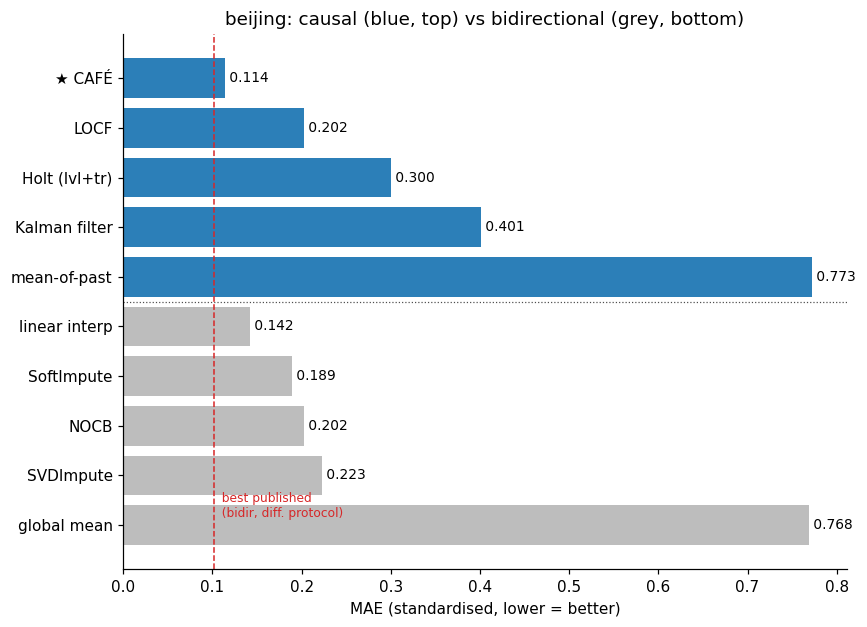

In [4]:
beijing.plot(); plt.tight_layout(); plt.show()

Blue = causal (top block), grey = bidirectional (below the dotted divider). The
dashed red line is the **best published bidirectional** score (CSDI 0.102, TSI-Bench) — drawn
as a *different-protocol context line*, not a like-for-like target. CAFÉ sits near it while
being the only backtest-safe option in the figure.

## 3 · The honest hard case — contiguous gaps

Scattered (MCAR) gaps are the easy case: a missing cell usually has observed neighbours in
its own row. The hard, realistic case is **block** missingness — a sensor goes dark for a
stretch. We don't hide from it; `pattern="block"` runs it on the **same Beijing slice,
10% held out**. Causal methods can't borrow from the future across a blackout, so the gap
is genuinely harder for everyone — but CAFÉ's factor + AR state still carries it, and it
still tops the live causal block.

In [5]:
cafe.benchmark("beijing", pattern="block", missing=0.1)

CAFÉ benchmark — beijing  (17117×132, 10% block missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.293    0.491   36.3%    5.97s ★
  mean-of-past        0.853    1.111  105.9%    0.03s
  Kalman filter       0.931    1.309  115.5%    0.20s
  LOCF                1.005    1.433  124.7%    0.01s
  Holt (lvl+tr)       1.247    1.744  154.7%    0.26s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.198    0.362   24.5%    0.49s
  SVDImpute           0.233    0.419   28.9%    1.03s
  linear interp       0.782    1.123   97.0%    0.02s
  global mean         0.831    1.089  103.1%    0.01s
  NOCB                0.952    1.341  118.2%    0.02s

PUBLISHED reference — CONTEXT ONLY, *not* a head-to-head leaderboard.
  All rows below are BIDIRECTIONAL + GPU (each fill sees the 

CAFÉ benchmark — beijing  (17117×132, 10% block missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.293    0.491   36.3%    5.97s ★
  mean-of-past        0.853    1.111  105.9%    0.03s
  Kalman filter       0.931    1.309  115.5%    0.20s
  LOCF                1.005    1.433  124.7%    0.01s
  Holt (lvl+tr)       1.247    1.744  154.7%    0.26s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.198    0.362   24.5%    0.49s
  SVDImpute           0.233    0.419   28.9%    1.03s
  linear interp       0.782    1.123   97.0%    0.02s
  global mean         0.831    1.089  103.1%    0.01s
  NOCB                0.952    1.341  118.2%    0.02s

PUBLISHED reference — CONTEXT ONLY, *not* a head-to-head leaderboard.
  All rows below are BIDIRECTIONAL + GPU (each fill sees the 

### Gap-length stratification

The research harness (`bench/exp_maskgrid.py`) sweeps a full **pattern × rate** grid
(Point/MCAR, Subsequence, Block × 10/30/50%) and stratifies one block run by **gap length**
(short / medium / long contiguous gaps), writing `paper/tables/maskgrid.tex`. Every cell
there is run *live on the same mask* — no competitor deep model is ever executed. We
reproduce the spirit of it here, **honestly and self-contained**, by scoring CAFÉ against
the live baselines as the block fraction grows: longer / denser blackouts are where any
*causal* method must give up the most, since it cannot look across the gap from the
future.

In [6]:
rates = [0.1, 0.2, 0.3, 0.4]
grid = {}
for rt in rates:
    r = cafe.benchmark("beijing", pattern="block", missing=rt, verbose=False)
    grid[rt] = {row["method"]: row["mae"] for row in r.rows if row["ok"]}

methods = ["CAFÉ", "LOCF", "linear interp", "SoftImpute"]
print(f"{'block %':>8s}" + "".join(f"{m:>15s}" for m in methods))
for rt in rates:
    print(f"{int(rt*100):>7d}%" + "".join(f"{grid[rt].get(m, float('nan')):>15.3f}" for m in methods))
print("\n(MAE, standardised, 10–40% Block mask on the Beijing slice; lower is better.")
print(" CAFÉ & LOCF are strictly causal; linear interp & SoftImpute are bidirectional.)")

 block %           CAFÉ           LOCF  linear interp     SoftImpute
     10%          0.293          1.005          0.782          0.198
     20%          0.284          0.979          0.806          0.209
     30%          0.287          0.940          0.791          0.212
     40%          0.318          0.953          0.809          0.226

(MAE, standardised, 10–40% Block mask on the Beijing slice; lower is better.
 CAFÉ & LOCF are strictly causal; linear interp & SoftImpute are bidirectional.)


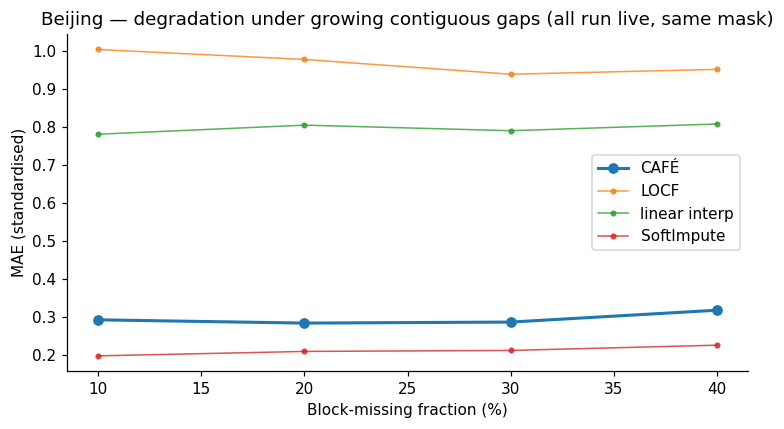

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for m in methods:
    ys = [grid[rt].get(m, np.nan) for rt in rates]
    style = dict(marker="o", lw=2) if m == "CAFÉ" else dict(marker=".", lw=1, alpha=0.8)
    ax.plot([int(rt*100) for rt in rates], ys, label=m, **style)
ax.set_xlabel("Block-missing fraction (%)")
ax.set_ylabel("MAE (standardised)")
ax.set_title("Beijing — degradation under growing contiguous gaps (all run live, same mask)")
ax.legend()
plt.tight_layout(); plt.show()

## 4 · Breadth — another real dataset, one line

`cafe.benchmark("etth1")` on the Electricity Transformer Temperature set (17,420 × 7), under
the same **10% MCAR / point mask on the standardized slice**. No published reference rows
here on purpose: the public ETT *imputation* numbers use a different protocol, so quoting
them would be apples-to-oranges — and this notebook never does that.

CAFÉ benchmark — etth1  (17420×7, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.240    0.367   31.0%    2.53s ★
  LOCF                0.249    0.400   32.1%    0.00s
  Holt (lvl+tr)       0.365    0.582   47.2%    0.15s
  Kalman filter       0.457    0.681   59.1%    0.14s
  mean-of-past        0.747    1.004   96.6%    0.00s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  linear interp       0.172    0.272   22.2%    0.00s
  NOCB                0.248    0.402   32.1%    0.00s
  SoftImpute          0.407    0.642   52.6%    0.02s
  SVDImpute           0.560    0.851   72.5%    0.03s
  global mean         0.753    1.006   97.4%    0.00s

★ = best causal method (CAFÉ vs causal baselines, run LIVE here).


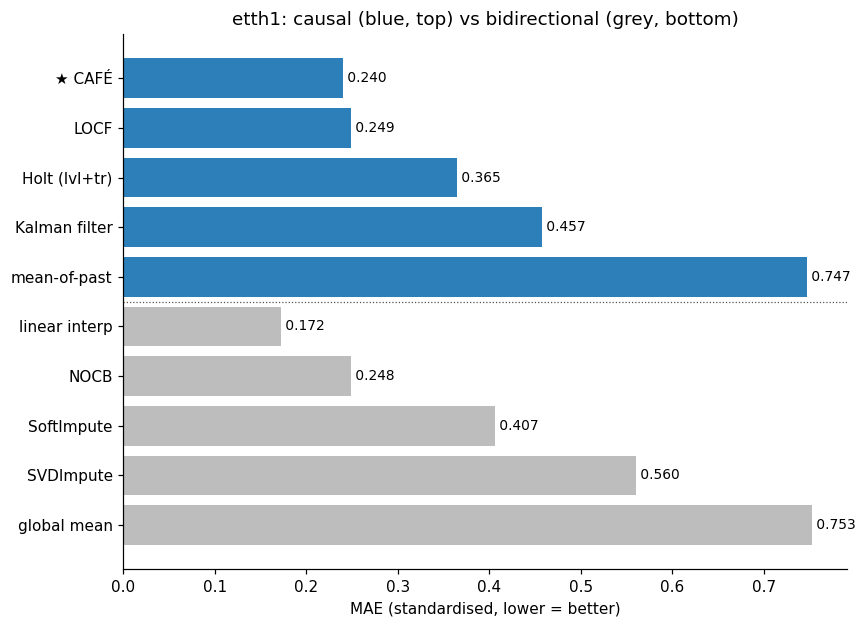

In [8]:
etth1 = cafe.benchmark("etth1", missing=0.1)
etth1.plot(); plt.tight_layout(); plt.show()

## 5 · It's the same one model behind everything

The benchmark imputer is the *same* `cafe.impute` you'd use in one line on your own data —
and the same forward pass yields uncertainty, factors, anomalies, a decomposition, a
dependency network and forecasts (see **`cafe_tutorial.ipynb`**). One model, every view of
its own posterior — all of it causal.

In [9]:
X = np.load("../data/ETTh1_clean.npy")[:800]          # a real matrix
X[np.random.default_rng(0).random(X.shape) < 0.1] = np.nan
res = cafe.CAFE().run(X)
print("imputed:", np.asarray(res.imputed).shape,
      "| factors:", res.factors().shape,
      "| anomaly:", np.asarray(res.anomaly_scores()).shape,
      "| params:", res.params)

imputed: (800, 7) | factors: (800, 8) | anomaly: (800,) | params: {'nu': 5.327665336712613, 'ar': 0.8741362184269934, 'effective_rank': 2}


## Recap

| One line | What it does |
|---|---|
| `cafe.impute(df)` | fill gaps, any container, **no look-ahead** |
| `cafe.benchmark(df)` | CAFÉ vs **live** baselines + cited SOTA *context*, scored honestly |
| `cafe.benchmark("beijing")` | reproduce the headline: causal CAFÉ **in the bidirectional band** |
| `cafe.CAFE().run(df)` | uncertainty, factors, anomalies, decomposition, network, forecast |

**The claim, stated precisely.** CAFÉ is **causal (point-in-time), CPU-only, zero-config**,
and lands in the **same MAE band** as GPU-trained bidirectional SOTA on the very benchmark
those methods report — measured under a **10% MCAR / point mask on the standardized dense
slice**. That is the **two-of-three**: causal + CPU + competitive. We do **not** claim the
single lowest MAE — under TSI-Bench, CSDI (0.102) is lower, and CAFÉ is never ranked
head-to-head against the different-protocol published numbers. The published numbers come
from one reconciled registry, [`bench/refs_published.py`](../bench/refs_published.py), which
keeps both values wherever two sources disagree.

```bash
pip install cafe-impute
```